In [57]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [58]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [59]:
X_train.shape

(60000, 28, 28)

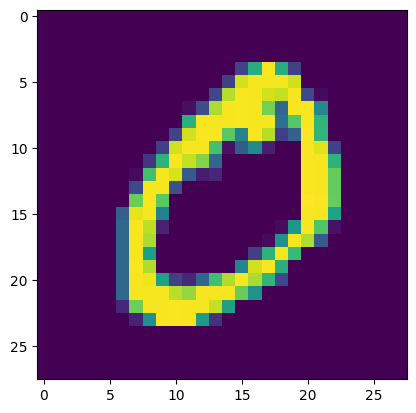

In [60]:
import matplotlib.pyplot as plt

plt.imshow(X_train[1])

In [61]:
X_train = X_train / 255
X_test = X_test / 255

In [62]:
model = Sequential()

model.add(Flatten(input_shape=(28,28)))

model.add(Dense(128,activation='relu'))
model.add(Dense(32,activation='relu'))

model.add(Dense(10,activation='softmax'))

/Users/kevin/Desktop/ai-engineer/deep-learning/.venv/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [63]:
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
model.compile(optimizer='Adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [65]:
history = model.fit(X_train, y_train, epochs=50, validation_split=0.2)

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 663us/step - accuracy: 0.9168 - loss: 0.2781 - val_accuracy: 0.9532 - val_loss: 0.1469
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 662us/step - accuracy: 0.9650 - loss: 0.1179 - val_accuracy: 0.9665 - val_loss: 0.1136
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 626us/step - accuracy: 0.9759 - loss: 0.0799 - val_accuracy: 0.9669 - val_loss: 0.1055
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 632us/step - accuracy: 0.9809 - loss: 0.0607 - val_accuracy: 0.9730 - val_loss: 0.0917
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - accuracy: 0.9851 - loss: 0.0469 - val_accuracy: 0.9716 - val_loss: 0.0963
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 679us/step - accuracy: 0.9888 - loss: 0.0347 - val_accuracy: 0.9721 - val_loss: 0.0923
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 676us/step - accuracy: 0.9899 - loss: 0.0312 - val_accuracy: 0.9713 - val_loss: 0.1126
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 659us/step - accuracy: 0.9918 -

In [66]:
y_prob = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 260us/step


In [67]:
y_pred = y_prob.argmax(axis=1)

In [68]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.9779

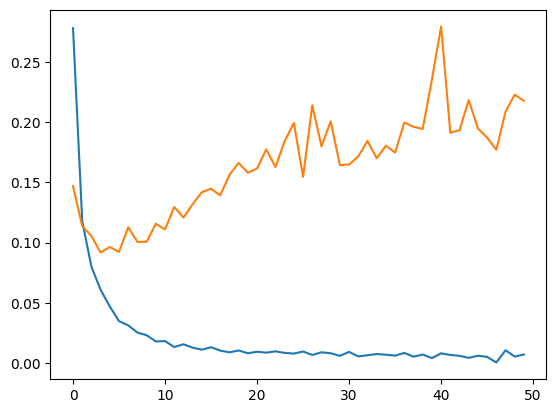

In [72]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

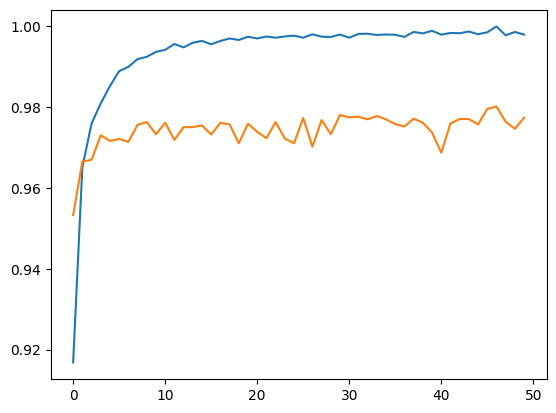

In [73]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

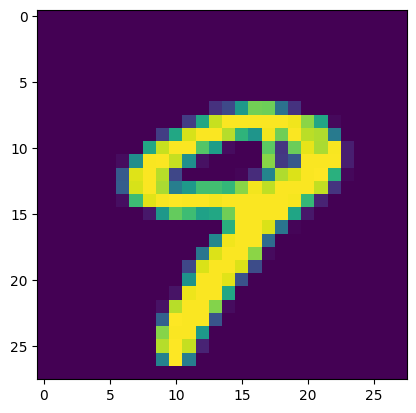

In [78]:
plt.imshow(X_test[9])

In [77]:
model.predict(X_test[9].reshape(1, 28, 28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


array([9])